# 长IR的卷积
为了简便，均使用uniform分块卷积  
我们已经在ola.ipynb里探索了`constant OLA`相关的东西  
其中有一个我很好奇，那就是smith提到的OLA修改时相当于IR的每个tap被窗函数滤波，限制了IR的变化  
因此，我认为可以试试能否对uniform分块卷积法应用这种特征  

## tests
所有的测试输入均为一个delta函数  
IR为一个长8192的在4096处发生频率跳变的正弦波组成  

# uniform分块卷积
fft_size = 512  
将IR切成fft_size个块，每个都零填充至两倍来阻止时间混叠  
使用rectangle窗口，在修改频域仍然保持COLA是一个特殊窗口，hop可以为fft_size/任意数  
这里将HOP设置为fft_size  

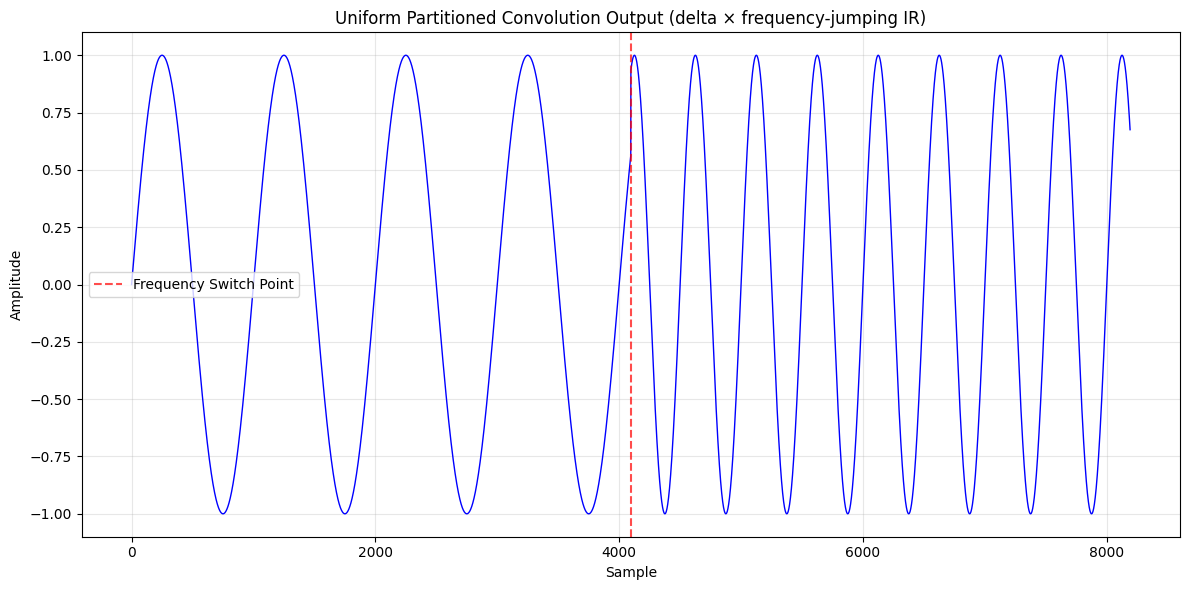

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 参数设置
# ==========================================
# ── 卷积参数 ──
fft_size = 512  # 帧长 / 每块长度
hop_size = fft_size  # Hop = 帧长（矩形窗，无重叠）
fft_conv_len = fft_size * 2  # 两倍零填充

# ── IR 参数 ──
ir_len = 8192  # IR 总长度
num_blocks = ir_len // fft_size  # IR 块数 = 16
ir_switch = ir_len // 2  # 频率跳变点 = 4096

# ── 信号参数 ──
x_len = ir_len * 2  # 输入总长度
fs = 1000  # 采样率
f_low = 1  # IR 前半段频率 (Hz)
f_high = 2  # IR 后半段频率 (Hz)

# ── 运行参数 ──
total_frames = x_len // fft_size + num_blocks  # 总帧数 = 基础帧 + 尾部排水帧

# ==========================================
# 2. 生成信号
# ==========================================
# 输入: delta 函数
x = np.zeros(x_len)
x[0] = 1.0

# IR: 在 ir_switch 处频率跳变的正弦波
n = np.arange(ir_len)
h = np.where(
    n < ir_switch,
    np.sin(2 * np.pi * f_low * n / fs),
    np.sin(2 * np.pi * f_high * n / fs),
)

# ==========================================
# 3. IR 分块 + 零填充 FFT 预处理
# ==========================================
H_blocks = []
for i in range(num_blocks):
    h_block = h[i * fft_size : (i + 1) * fft_size]
    H_i = np.fft.fft(h_block, n=fft_conv_len)
    H_blocks.append(H_i)

# ==========================================
# 4. 分块卷积主循环
# ==========================================
# 输出缓冲区
out = np.zeros(x_len + fft_conv_len * num_blocks)

# FFT 环形缓冲区: 长度 = num_blocks，每项是长度 fft_conv_len 的复数数组
X_buf = [np.zeros(fft_conv_len, dtype=complex) for _ in range(num_blocks)]

for k in range(total_frames):
    # 4a. 取当前帧 → 零填充 → FFT
    start = k * fft_size
    if start + fft_size <= len(x):
        x_frame = x[start : start + fft_size]
    else:
        x_frame = np.zeros(fft_size)
    X = np.fft.fft(x_frame, n=fft_conv_len)

    # 4b. 更新环形缓冲区 (FIFO: 新帧插入头部，最旧的丢弃)
    X_buf = [X] + X_buf[:-1]

    # 4c. 频域累加点积: X_buf[p] × H_blocks[p] for all p
    Y_accum = np.zeros(fft_conv_len, dtype=complex)
    for p in range(num_blocks):
        Y_accum += X_buf[p] * H_blocks[p]

    # 4d. 单次 IFFT → OLA
    y = np.fft.ifft(Y_accum).real
    out[start : start + fft_conv_len] += y

# 截取有效卷积长度
out = out[:ir_len]

# ==========================================
# 5. 输出波形图
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(out, color="blue", linewidth=1.0)
plt.axvline(
    x=4096, color="red", linestyle="--", alpha=0.7, label="Frequency Switch Point"
)
plt.title("Uniform Partitioned Convolution Output (delta × frequency-jumping IR)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# uniform分块卷积, 但不是矩形窗
fft_size = 512  
将IR切成fft_size个块，每个都零填充至两倍来阻止时间混叠  
使用hann窗口，在修改频域时要保持COLA，那么hop必须为fft_size/M，其中M>=4  

## after
有意思，我发现M>=2也能保持COLA  
更有意思的是计算过程  
输入的fft环形缓冲区要变为M倍于IR的环形缓冲区大小  
从输入fft环形缓冲区第0个开始，每隔M个取下一个fft vec，与ir vec相乘，然后叠加起来  
进行ifft得到了输出块  

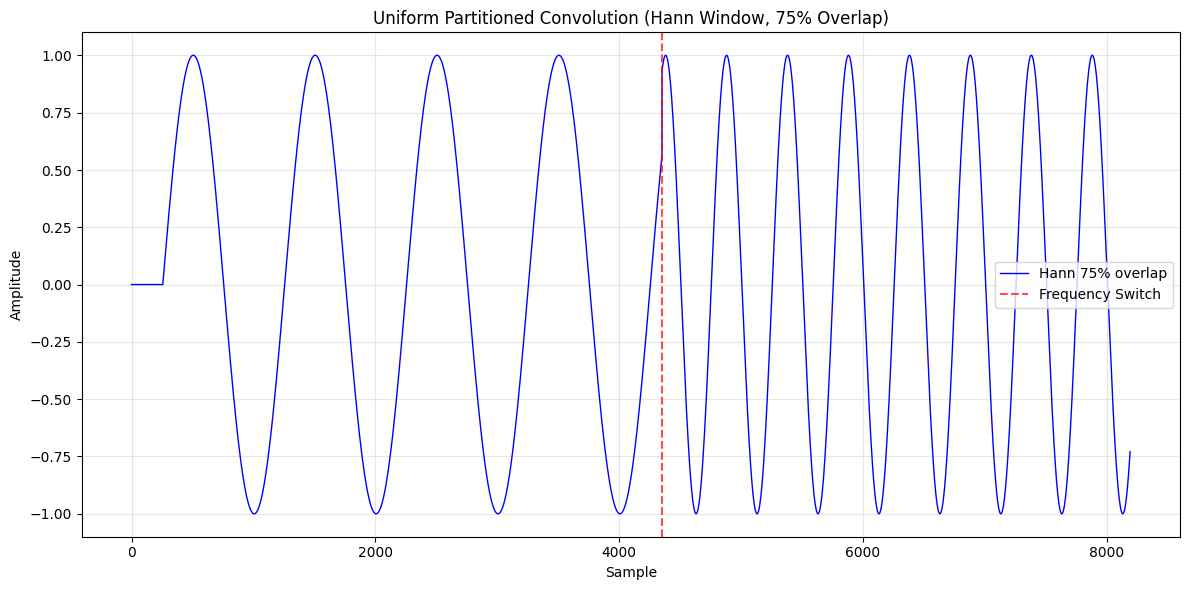

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 参数设置
# ==========================================
# ── 卷积参数 ──
fft_size = 512
hop_size = fft_size // 4  # 128, 75% 重叠
fft_conv_len = fft_size * 2  # 1024, 两倍零填充

# ── IR 参数 ──
ir_len = 8192
num_blocks = ir_len // fft_size  # 16
ir_switch = ir_len // 2  # 4096

# ── 信号参数 ──
x_len = ir_len * 2
fs = 1000
f_low = 1
f_high = 2

# ── 运行参数 ──
buf_len = num_blocks * fft_size // hop_size  # 64 = X_buf 环形缓冲区大小
total_frames = x_len // hop_size + buf_len  # 总帧数

# ==========================================
# 2. 生成信号
# ==========================================
# 输入: delta 放在第一帧窗中心 (Hann 窗边界为 0)
x = np.zeros(x_len)
x[fft_size // 2] = 1.0

# IR: 在 ir_switch 处频率跳变的正弦波
n = np.arange(ir_len)
h = np.where(
    n < ir_switch,
    np.sin(2 * np.pi * f_low * n / fs),
    np.sin(2 * np.pi * f_high * n / fs),
)

# ==========================================
# 3. IR 分块 + 零填充 FFT 预处理
# ==========================================
H_blocks = []
for i in range(num_blocks):
    H_i = np.fft.fft(h[i * fft_size : (i + 1) * fft_size], n=fft_conv_len)
    H_blocks.append(H_i)

# ==========================================
# 4. 分块卷积主循环 (Hann 窗 + 75% 重叠)
# ==========================================
win = np.hanning(fft_size)
out = np.zeros(total_frames * hop_size + fft_conv_len)

# FFT 环形缓冲区: 64 项, 每项长度 1024 复数
X_buf = [np.zeros(fft_conv_len, dtype=complex) for _ in range(buf_len)]

for k in range(total_frames):
    start = k * hop_size

    # 4a. 取帧 → Hann 加窗 → 零填充 → FFT
    if start + fft_size <= len(x):
        x_frame = x[start : start + fft_size] * win
    else:
        x_frame = np.zeros(fft_size)
    X = np.fft.fft(x_frame, n=fft_conv_len)

    # 4b. 更新环形缓冲区 (FIFO)
    X_buf = [X] + X_buf[:-1]

    # 4c. 频域累加点积
    # IR 块 p 延时 = p * fft_size, 帧步进 = hop_size
    # 对应帧索引偏移 = p * fft_size / hop_size = 4p
    Y_accum = np.zeros(fft_conv_len, dtype=complex)
    for p in range(num_blocks):
        Y_accum += X_buf[4 * p] * H_blocks[p]

    # 4d. 单次 IFFT → OLA
    # Hann 75% 重叠时 COLA 增益 = 1.5, 归一化
    y = np.fft.ifft(Y_accum).real / 1.5
    out[start : start + fft_conv_len] += y

out = out[:ir_len]

# ==========================================
# 5. 输出波形图
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(out, color="blue", linewidth=1.0, label="Hann 75% overlap")
# plt.plot(h, color="orange", alpha=0.5, linewidth=1.0, label="IR (reference)")
plt.axvline(
    x=ir_switch + fft_size // 2,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Frequency Switch",
)
plt.title("Uniform Partitioned Convolution (Hann Window, 75% Overlap)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 问题
不难发现，如果输入切分后，恰好在窗函数的0处  
比如使用hann窗，输入是一个位于0的delta  
将会什么都不会输出  
---
替换OLA为WOLA  
输入为矩形窗，输出加hann窗  
仍然保持hop = fft_size / M, M>=4  

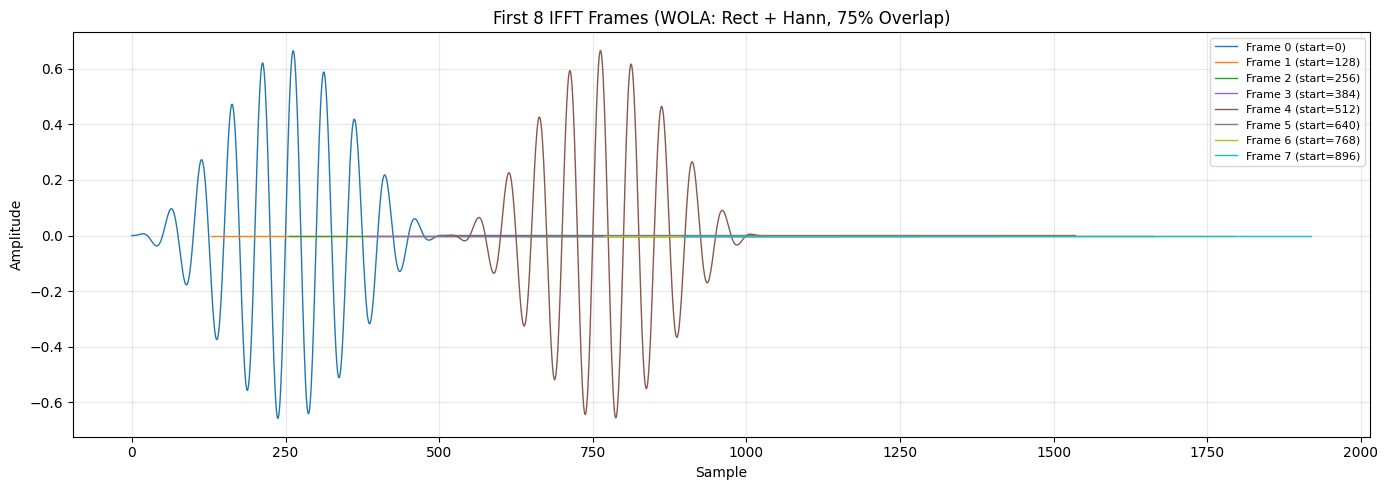

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 参数设置（同 Cell 7）
# ==========================================
# ── 卷积参数 ──
fft_size = 512
hop = 4
hop_size = fft_size // hop       # 128, 75% 重叠
fft_conv_len = fft_size * 2     # 1024, 两倍零填充

# ── IR 参数 ──
ir_len = 8192
num_blocks = ir_len // fft_size  # 16
ir_switch = ir_len // 2          # 4096

# ── 信号参数 ──
x_len = ir_len * 2
fs = 1000
f_low = 20
f_high = 200

# ── 运行参数 ──
buf_len = num_blocks * fft_size // hop_size   # 64
total_frames = x_len // hop_size + buf_len

# ==========================================
# 2. 生成信号（同 Cell 7）
# ==========================================
x = np.zeros(x_len)
x[0] = 1.0

n = np.arange(ir_len)
h = np.where(
    n < ir_switch,
    np.sin(2 * np.pi * f_low * n / fs),
    np.sin(2 * np.pi * f_high * n / fs),
)

# ==========================================
# 3. IR 分块预处理
# ==========================================
H_blocks = []
for i in range(num_blocks):
    H_i = np.fft.fft(h[i * fft_size : (i + 1) * fft_size], n=fft_conv_len)
    H_blocks.append(H_i)

# ==========================================
# 4. 主循环 + 记录前 8 帧
# ==========================================
win = np.hanning(fft_size)
win_pad = np.pad(win, (0, fft_size))

out = np.zeros(total_frames * hop_size + fft_conv_len)
X_buf = [np.zeros(fft_conv_len, dtype=complex) for _ in range(buf_len)]

frames_record = []  # 记录 (start, y_win) 用于绘图

for k in range(total_frames):
    start = k * hop_size

    if start + fft_size <= len(x):
        x_frame = x[start : start + fft_size]
    else:
        x_frame = np.zeros(fft_size)
    X = np.fft.fft(x_frame, n=fft_conv_len)

    X_buf = [X] + X_buf[:-1]

    Y_accum = np.zeros(fft_conv_len, dtype=complex)
    for p in range(num_blocks):
        Y_accum += X_buf[hop * p] * H_blocks[p]

    y = np.fft.ifft(Y_accum).real
    y_win = y * win_pad / 1.5
    out[start : start + fft_conv_len] += y_win

    if k < 8:
        frames_record.append((start, y_win))

# ==========================================
# 5. 绘图: 前 8 帧独立曲线（按起始位置对齐）
# ==========================================
plt.figure(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for idx, (pos, frame) in enumerate(frames_record):
    x_axis = np.arange(pos, pos + fft_conv_len)
    plt.plot(x_axis, frame, color=colors[idx], linewidth=1.0,
             label=f"Frame {idx} (start={pos})")

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 8 IFFT Frames (WOLA: Rect + Hann, 75% Overlap)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# after
有趣，居然需要IR也进行重叠分块

IR frames = 31, COLA gain = 1.0


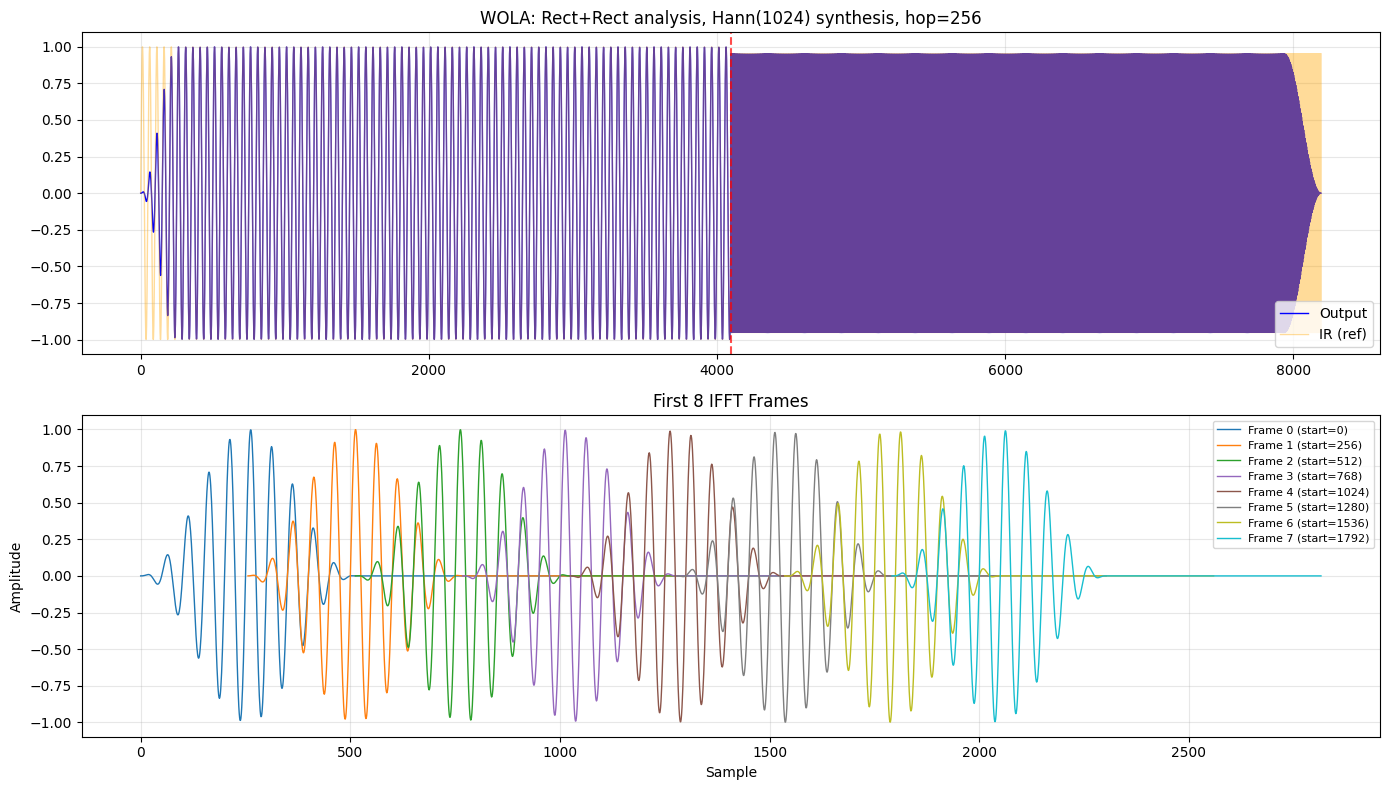

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 参数设置
# ==========================================
# ── 卷积参数 ──
fft_size = 512
hop = 2
hop_size = fft_size // hop          # 128
fft_conv_len = fft_size * 2         # 1024

# ── IR 参数 ──
ir_len = 8192
ir_switch = ir_len // 2             # 4096

# ── 信号参数 ──
x_len = ir_len * 2
fs = 1000
f_low = 20
f_high = 200

# ── IR 重叠分帧参数 ──
num_ir_frames = (ir_len - fft_size) // hop_size + 1   # 61
buf_len = num_ir_frames                                # 环形缓冲区大小 = 61
total_frames = x_len // hop_size + buf_len

# ── WOLA 参数 ──
win_s = np.pad(np.hanning(fft_size), (0, fft_size))    # 合成窗: 前512=Hann, 后512=0
cola_gain = fft_size / (2 * hop_size)                  # = 2.0

print(f"IR frames = {num_ir_frames}, COLA gain = {cola_gain}")

# ==========================================
# 2. 生成信号
# ==========================================
x = np.zeros(x_len)
x[0] = 1.0

n = np.arange(ir_len)
h = np.where(
    n < ir_switch,
    np.sin(2 * np.pi * f_low * n / fs),
    np.sin(2 * np.pi * f_high * n / fs),
)

# ==========================================
# 3. IR 重叠分帧预处理
# ==========================================
IR_buf = []  # 长度 = num_ir_frames, 每项长度 1024 复数
for p in range(num_ir_frames):
    h_frame = h[p * hop_size : p * hop_size + fft_size]  # 矩形窗
    H_p = np.fft.fft(h_frame, n=fft_conv_len)
    IR_buf.append(H_p)

# ==========================================
# 4. 主循环 (X_buf[p] · IR_buf[p])
# ==========================================
out = np.zeros(total_frames * hop_size + fft_conv_len)
X_buf = [np.zeros(fft_conv_len, dtype=complex) for _ in range(buf_len)]
frames_record = []

for k in range(total_frames):
    start = k * hop_size

    # 矩形窗分析
    if start + fft_size <= len(x):
        x_frame = x[start : start + fft_size]
    else:
        x_frame = np.zeros(fft_size)
    X = np.fft.fft(x_frame, n=fft_conv_len)

    # 环形缓冲区
    X_buf = [X] + X_buf[:-1]

    # 点积: X_buf[p] · IR_buf[p]  ← 同索引对齐
    Y_accum = np.zeros(fft_conv_len, dtype=complex)
    for p in range(num_ir_frames):
        Y_accum += X_buf[p] * IR_buf[p]

    # IFFT → 合成窗 → OLA
    y = np.fft.ifft(Y_accum).real
    y_win = y * win_s / cola_gain
    out[start : start + fft_conv_len] += y_win

    if k < 8:
        frames_record.append((start, y_win))

out = out[:ir_len]

# ==========================================
# 5. 绘图
# ==========================================
plt.figure(figsize=(14, 8))

# 5a. 输出 vs IR 参考
plt.subplot(2, 1, 1)
plt.plot(out, color="blue", linewidth=1.0, label="Output")
plt.plot(h, color="orange", alpha=0.4, linewidth=1.0, label="IR (ref)")
plt.axvline(x=ir_switch, color="red", linestyle="--", alpha=0.7)
plt.title(f"WOLA: Rect+Rect analysis, Hann({fft_conv_len}) synthesis, hop={hop_size}")
plt.grid(True, alpha=0.3)
plt.legend()

# 5b. 前 8 帧
plt.subplot(2, 1, 2)
colors = plt.cm.tab10(np.linspace(0, 1, 8))
for idx, (pos, frame) in enumerate(frames_record):
    x_axis = np.arange(pos, pos + fft_conv_len)
    plt.plot(x_axis, frame, color=colors[idx], linewidth=1.0,
             label=f"Frame {idx} (start={pos})")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 8 IFFT Frames")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 数学验证
todo